In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [3]:
customers = pd.read_csv("../data/raw/olist_customers_dataset.csv")
geolocation = pd.read_csv("../data/raw/olist_geolocation_dataset.csv")
order_items = pd.read_csv("../data/raw/olist_order_items_dataset.csv")
order_payments = pd.read_csv("../data/raw/olist_order_payments_dataset.csv")
order_reviews = pd.read_csv("../data/raw/olist_order_reviews_dataset.csv")
orders = pd.read_csv("../data/raw/olist_orders_dataset.csv")
products = pd.read_csv("../data/raw/olist_products_dataset.csv")
sellers = pd.read_csv("../data/raw/olist_sellers_dataset.csv")
category_translation = pd.read_csv("../data/raw/product_category_name_translation.csv")

Проанализируем статусы заказов и их доли:

In [5]:
order_status_counts = (orders["order_status"].value_counts(normalize=True) * 100).round(2)
order_status_counts

order_status
delivered      97.02
shipped         1.11
canceled        0.63
unavailable     0.61
invoiced        0.32
processing      0.30
created         0.01
approved        0.00
Name: proportion, dtype: float64

Для наглядности построим график:

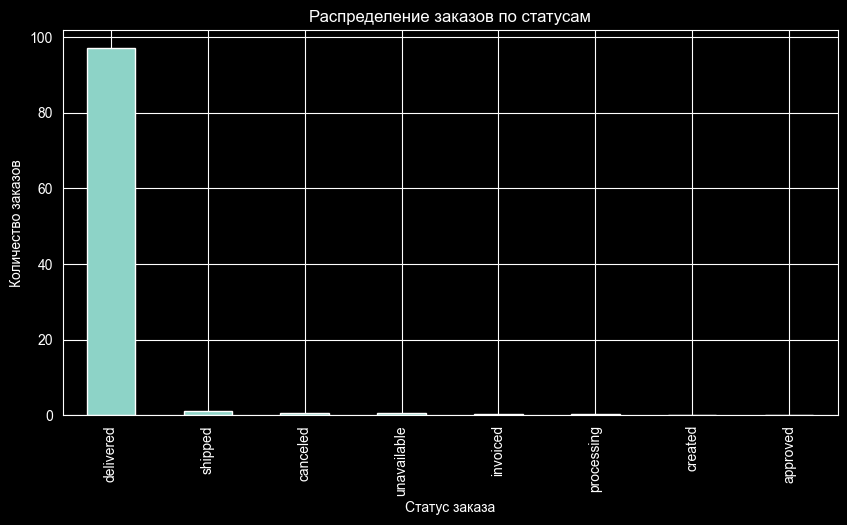

In [13]:
plt.figure(figsize=(10, 5))
order_status_counts.plot(kind="bar")
plt.title("Распределение заказов по статусам")
plt.xlabel("Статус заказа")
plt.ylabel("Количество заказов")
plt.show()

Дальше нужно проверить все типы данных и откорректировать если потребуется

In [14]:
orders.dtypes

order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str
dtype: object

Исправляем тип в orders на date:

In [17]:
orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"])
orders["order_approved_at"] = pd.to_datetime(orders["order_approved_at"])
orders["order_delivered_carrier_date"] = pd.to_datetime(orders["order_delivered_carrier_date"])
orders["order_delivered_customer_date"] = pd.to_datetime(orders["order_delivered_customer_date"])
orders["order_estimated_delivery_date"] = pd.to_datetime(orders["order_estimated_delivery_date"])

In [18]:
orders.dtypes

order_id                                    str
customer_id                                 str
order_status                                str
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object

In [19]:
order_reviews.dtypes

review_id                    str
order_id                     str
review_score               int64
review_comment_title         str
review_comment_message       str
review_creation_date         str
review_answer_timestamp      str
dtype: object

In [22]:
order_reviews["review_creation_date"] = pd.to_datetime(order_reviews["review_creation_date"])
order_reviews["review_answer_timestamp"] = pd.to_datetime(order_reviews["review_answer_timestamp"])

In [23]:
order_reviews.dtypes

review_id                             str
order_id                              str
review_score                        int64
review_comment_title                  str
review_comment_message                str
review_creation_date       datetime64[us]
review_answer_timestamp    datetime64[us]
dtype: object

In [24]:
order_items.dtypes

order_id                   str
order_item_id            int64
product_id                 str
seller_id                  str
shipping_limit_date        str
price                  float64
freight_value          float64
dtype: object

In [25]:
order_items["shipping_limit_date"] = pd.to_datetime(order_items["shipping_limit_date"])

In [26]:
order_items.dtypes

order_id                          str
order_item_id                   int64
product_id                        str
seller_id                         str
shipping_limit_date    datetime64[us]
price                         float64
freight_value                 float64
dtype: object

Даты готовы, теперь можно проанализировать данные для пропусков, чтобы было возможо провести качественное исследование

In [30]:
missing_checks = pd.DataFrame({
    "check": [
        "orders: дата покупки",
        "orders: фактическая дата доставки",
        "orders: ожидаемая дата доставки",
        "order_items: цена товара",
        "order_items: стоимость доставки",
        "order_reviews: оценка клиента",
        "products: категория товара",
        "order_payments: способ оплаты",
        "order_payments: сумма платежа"
    ],
    "missing_count": [
        sum(orders["order_purchase_timestamp"].isna()),
        sum(orders["order_delivered_customer_date"].isna()),
        sum(orders["order_estimated_delivery_date"].isna()),
        sum(order_items["price"].isna()),
        sum(order_items["freight_value"].isna()),
        sum(order_reviews["review_score"].isna()),
        sum(products["product_category_name"].isna()),
        sum(order_payments["payment_type"].isna()),
        sum(order_payments["payment_value"].isna())
    ]
})

missing_checks

,check,missing_count
0,orders: дата покупки,0
1,orders: фактическая дата доставки,2965
2,orders: ожидаемая дата доставки,0
3,order_items: цена товара,0
4,order_items: стоимость доставки,0
5,order_reviews: оценка клиента,0
6,products: категория товара,610
7,order_payments: способ оплаты,0
8,order_payments: сумма платежа,0


Пропуски у фактической даты доставки обьясняются тем, что не все заказы со статусом "доставлен", а пропускт в категории товара нужно будет учитывать при анализе категорий.
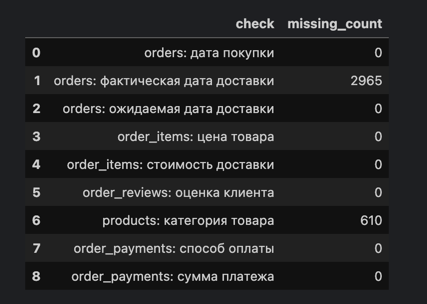

Дальше попробуем подтвердить, что пропуски фактической даты доставки есть только у заказов со статусом, отличным от "доставлен"

In [40]:
delivered_orders = orders[orders["order_status"] == "delivered"]
missing_delivered_dates = sum(delivered_orders["order_delivered_customer_date"].isna())

missing_delivered_dates

8

Эти 8 строк следует исключить из данных, так как по ним будет невозможно корректно провести исследование.

In [52]:
delivered_orders_clean = delivered_orders.dropna(subset=["order_delivered_customer_date"])

In [53]:
missing_delivered_orders_clean = sum(delivered_orders_clean["order_delivered_customer_date"].isna())
missing_delivered_orders_clean

0

Далее нужно посмотреть на дубликаты в таблицах и проверить уникальность каждого ключа

In [56]:
print(sum(orders.duplicated()))
print(sum(order_items.duplicated()))
print(sum(order_payments.duplicated()))
print(sum(order_reviews.duplicated()))
print(sum(customers.duplicated()))
print(sum(products.duplicated()))
print(sum(sellers.duplicated()))

0
0
0
0
0
0
0


полных дубликатов нет, можем продолжать

In [64]:
print(orders["order_id"].is_unique)
print(customers["customer_id"].is_unique)
print(products["product_id"].is_unique)
print(sellers["seller_id"].is_unique)

True
True
True
True


Выбросы и аномальные данные:

In [70]:
price_checks = pd.DataFrame({
    "names": ["neg_price", "zero_price", "negative_freight", "zero_freight"],
    "values": [sum(order_items["price"] < 0),
               sum(order_items["price"] == 0),
               sum(order_items["freight_value"] < 0),
               sum(order_items["freight_value"] == 0),
               ]
})
price_checks

,names,values
0,neg_price,0
1,zero_price,0
2,negative_freight,0
3,zero_freight,383


Запомним условие, что доставка может быть бесплатной

In [71]:
order_items[["price", "freight_value"]].describe()

,price,freight_value
count,112650.000000,112650.000000
mean,120.653739,19.990320
std,183.633928,15.806405
min,0.850000,0.000000
25%,39.900000,13.080000
50%,74.990000,16.260000
75%,134.900000,21.150000
max,6735.000000,409.680000


Дальше проверим корректность дат:

In [78]:
print(sum(orders["order_approved_at"] < orders["order_purchase_timestamp"]))
print(sum(orders["order_delivered_carrier_date"] < orders["order_purchase_timestamp"]))
print(sum(orders["order_delivered_customer_date"] < orders["order_purchase_timestamp"]))
print(sum(orders["order_estimated_delivery_date"] < orders["order_purchase_timestamp"]))


0
166
0
0


In [80]:
orders["carrier_date_before_purchase"] = (
    orders["order_delivered_carrier_date"] < orders["order_purchase_timestamp"]
)
orders["carrier_date_before_purchase"].sum()
orders[orders["carrier_date_before_purchase"]].head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,carrier_date_before_purchase
615,b9afddbdcfadc9a87b41a83271c3e888,85c6af75161b8b2b1af98e82b5a6a5a5,delivered,2018-08-16 13:50:48,2018-08-16 14:05:13,2018-08-16 13:27:00,2018-08-24 14:58:37,2018-09-04,True
1111,ad133696906f6a78826daa0911b7daec,e6f5b234bb0d847f10eebd70130c5d49,delivered,2018-06-15 15:41:22,2018-06-15 16:19:23,2018-06-15 14:52:00,2018-06-22 18:09:37,2018-07-18,True
1329,74e033208dc13a7b8127eb8e73d09b76,72fcbb1145f2889eddcba6d6c1d6c090,delivered,2018-05-02 10:48:44,2018-05-02 11:13:45,2018-05-02 09:49:00,2018-05-07 23:06:36,2018-05-29,True
1372,a6b58794fd2ba533359a76c08df576e3,ccd8e3459ad58ae538c9d2cf35532ba4,delivered,2018-05-14 15:18:23,2018-05-14 15:33:35,2018-05-14 13:46:00,2018-05-19 19:33:32,2018-06-08,True
1864,5792e0b1c8c8a2bf53af468c9a422c88,5c427f06e7fcf902e309743516e2c580,delivered,2018-07-26 13:25:14,2018-07-26 13:35:14,2018-07-26 12:42:00,2018-07-30 14:45:02,2018-08-09,True


Для основного анализа доставки и расчета выручки данная аномалия не повлияет, в сравнении с остальным обьемом данных, аномальных значений мало, поэтому можно и оставить и в будущем исключать из выборки, если понадобится.

Итоговые ограничения:
- Анализ доставки нужно строить только по доставленным заказам с заполненной фактической датой доставки.
- Анализ отзывов и CSAT отражает только заказы, по которым клиент оставил оценку.
- При объединении таблиц нужно учитывать, что один заказ может иметь несколько товарных позиций, платежей или отзывов.
- Для категорий без названия или перевода нужно создать группу `Unknown`.
- Таблица `geolocation` требует отдельной агрегации перед расчётом расстояний, так как один zip-code prefix может встречаться несколько раз.